In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches



In [3]:
#中间矩阵
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A, Bz, yweizhi):

    return ((-B/(a**2))*sz - (1j/2)*A*sx) * np.exp((2*np.pi*1j*a**2)*Bz*(yweizhi-50))

def h_y(B, a, A):
    return (-B/(a**2))*sz - (1j/2)*A*sy

def h_onstie(m, B, a, u):

    return h_k(m, B, a) - u*s0

def t_x(B, a, A, Bz, yweizhi):

    return h_x(B, a, A, Bz, yweizhi)

def t_y(B, a, A):

    return h_y(B, a, A)


def H_onstie(m, B, a, u_set, xshumu, Nd, A, Bz, yweizhi):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A, Bz, yweizhi)

        if i > 0:
            H[i][i-1] = t_x(B, a, A, Bz, yweizhi).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = t_y(B, a, A)

    H = np.block(H)
    return H


m = 0.5       # 质量项
A = 1.0        # 费米速度项
B = -0.5        # 二阶动量项
Bz = 0.05     # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 10
xshumu = 10
yweizhi =2

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz, yweizhi)
# 动态生成中心区哈密顿量列表
#H_q_list = []
#for i in range(yshumu):
#    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz, i)
#    H_q_list.append(H_q_i)

# 层间跃迁矩阵
T_21 = H_hop(B, a, A, xshumu, Nd)



# 对于标准的纯 QAH，当 m*B < 0 时处于拓扑非平庸相 (陈数 C=1 或 -1)
if m * B < 0:
    leiN = 1  # Topological
else:
    leiN = 0  # Trivial

params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

save_dir = rf"D:\结果\2026.4.18"
os.makedirs(save_dir, exist_ok=True)

def save_fig_by_title_1(name):
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
    filename = os.path.join(save_dir, safe_name + ".png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

save = True 


Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 13484.65it/s]


已保存图片: D:\结果\2026.4.18\leiN=1_m=-0.5_A=1.0_B=0.5_x=10_uS=0_Ex=0_Bz=0.05.png
1


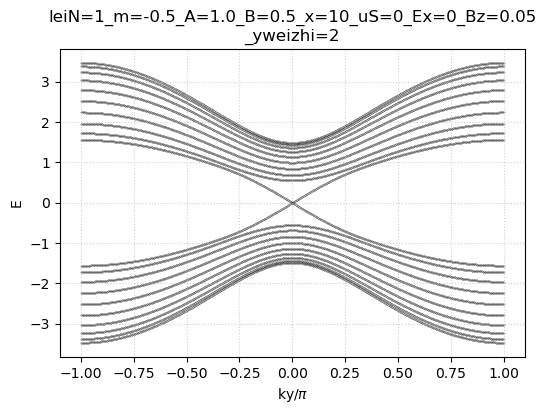

In [95]:
# 中间能带
ks1 = np.linspace(-1*np.pi, 1*np.pi,1001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.01)
#plt.ylim(-1.5,1.5)
#plt.xlim(-0.5,0.5)
#plt.ylim(-0.6,0.6)
#plt.xlim(-0.2,0.2)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}'+'\n'+f'_yweizhi={yweizhi}')
plt.grid(True, linestyle=':', alpha=0.6)
save_fig_by_title_1(params_str)
print(leiN)
plt.show()

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from tqdm import tqdm

# 假设 H_q 和 T_21 已经由前面 2x2 的代码生成
# 本征态
k_target = 0.03 * np.pi
# 计算 k 时的哈密顿量 (这里假设你的 Hk 函数已经定义好)
H_k0 = Hk(k_target, H_q, T_21)

# 注意：去掉了字符串里的 del={delta}，因为 2x2 系统不再有超导项
param_folder = f"leiN={leiN}_k={k_target:.4f}_m={m}_A={A}_B={B}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
save_dir = rf"D:\结果\2026.4.18下\{param_folder}"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 求解本征值和本征态
evals, evecs = np.linalg.eigh(H_k0)

Nd = 2  # 核心修改 1：现在每个格点只有 2 个自由度 (e↑, e↓)
print(f"\n开始计算 k={k_target} 的本征态波函数...")
print(f"共 {len(evals)} 个态，正在保存至 {save_dir} ...")

# 核心修改 2：sz 算符降维，只保留电子的极化权重
sz_local = np.array([1, -1])  # 对应 (e↑, e↓) 的自旋/轨道极化权重

# 扩展成整个波函数长度的极化权重向量 (长度为 Nd * xshumu)
Sz_weights = np.tile(sz_local, xshumu)

for i in tqdm(range(len(evals)), desc="Saving Wavefunctions"):
    E = evals[i]
    psi = evecs[:, i] 
    
    # ---------------- 计算 Sz 期望值 ----------------
    prob = np.abs(psi)**2
    # 归一化波函数概率
    prob = prob / np.sum(prob) 
    
    # 计算极化期望值
    sz_exp = np.sum(prob * Sz_weights)
    # --------------------------------------------------------
    
    # 画图：
    plt.figure(figsize=(10, 5))
    
    # 核心修改 3：只需要 2 种颜色：红(e↑), 蓝(e↓)
    color_map = ['#d62728', '#1f77b4'] 
    
    # 循环生成 柱子的颜色
    colors = [color_map[j % Nd] for j in range(xshumu * Nd)]
    
    # 画柱状图，X轴从 0 到 Nd*xshumu - 1
    x_positions = np.arange(xshumu * Nd)
    plt.bar(x_positions, prob, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # 画垂直的灰色虚线，把第0个格点、第1个格点...隔开
    for j in range(xshumu + 1):
        plt.axvline(x=j * Nd - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 设置图表标题和坐标轴
    plt.title(fr"Detailed {xshumu*Nd}-Component Probability (k={k_target:.4f})\n$E = {E:.4f}$, $\langle S_z \rangle = {sz_exp:.4f}$", fontsize=16)
    plt.xlabel(fr"Component Index (0 to {Nd*xshumu-1})", fontsize=14)
    plt.ylabel(r"$|\psi|^2$", fontsize=14)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.xticks(x_positions, x_positions, fontsize=7)
    plt.xlim(-1, xshumu * Nd)
    # plt.ylim(0, 0.2) # 如果需要看清微小概率可以取消注释
    
    # 核心修改 4：图例只保留电子项
    labels = [r'Electron $\uparrow$ (e_up)', r'Electron $\downarrow$ (e_dn)']
    patches = [mpatches.Patch(color=color_map[k], label=labels[k]) for k in range(Nd)]
    plt.legend(handles=patches, loc='upper right')
    
    # 文件命名依然加上 Sz 期望值
    filename = f"E_{E:.4f}_Sz_{sz_exp:.4f}_idx_{i}.png"
    filepath = os.path.join(save_dir, filename)
    
    # 保存并关闭画布
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()

print("全部波函数图片保存完毕！")


开始计算 k=0.09424777960769379 的本征态波函数...
共 20 个态，正在保存至 D:\结果\2026.4.18下\leiN=1_k=0.0942_m=-0.5_A=1.0_B=0.5_x=10_uS=0_Ex=0_Bz=0.005 ...


Saving Wavefunctions: 100%|██████████| 20/20 [00:03<00:00,  5.31it/s]

全部波函数图片保存完毕！


In [118]:
# 两边纳米线 (2x2 正常态)
# ==========================================

def H_onsite_1(mx, mz, Bjiao, t):
    # 移除了超导项 Delta 和冗余的 weizhi 判断，直接返回 2x2 正常态在位能
    HX_block = -(mu - 2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz + mx*np.cos(Bjiao)*sx
    return HX_block

def H_hop_1(af, t):
    # 移除了 4x4 的 block 组装，直接返回 2x2 跃迁矩阵
    # 注意：这里调用了全局变量 a
    H_X_right_to_left_hop_block = -1 * (t*s0 + 1j*af*sz/(1*a))
    return H_X_right_to_left_hop_block

# ==========================================
# 参数设置
# ==========================================
t = 2
af = 50
mu = 0.5

# 两边磁场与塞曼场参数
hx = 0    # 0.5
hz = 0    # 0.95
saimanjiao = np.pi * 0

# ==========================================
# 生成左右电极的哈密顿量
# ==========================================
# 左边矩阵信息
H_L_onsite = H_onsite_1(hx, hz, saimanjiao, t)
H_L_right_to_left_hop = H_hop_1(0, t)

# 右边矩阵信息 (在无超导且磁场对称的情况下，与左边一致)
H_R_onsite = H_onsite_1(hx, hz, saimanjiao, t)
H_R_right_to_left_hop = H_hop_1(0, t)

# 输入给格林函数计算模块的最终矩阵
H_l = H_L_onsite
T_l = H_L_right_to_left_hop

H_r = H_R_onsite
T_r = H_R_right_to_left_hop.conj().T

# ==========================================
# 构建电极与中心区的耦合矩阵 (T_LD, T_RD)
# ==========================================
# 核心修改：每个格点的自由度降为 2
Nd = 2

# 左电极耦合矩阵
T_LD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_LD[:, -Nd:] = H_hop_1(0, t*0.5).conj().T
#T_LD[:, :Nd] = H_hop_1(0, t*0.7).conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_RD[:, -Nd:] = H_hop_1(0, t*0.5)
#T_RD[:, 0:Nd] = H_hop_1(0, t*0.7).conj().T

开始计算纯能带结构...


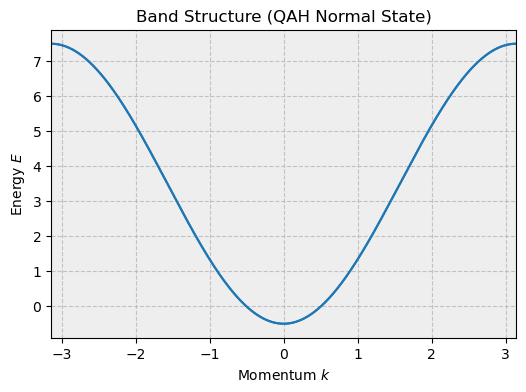

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 右电极能带计算 (极简提速版)
# ==========================================

ks = np.linspace(-np.pi, np.pi, 3001)

def Hk(k, H, T):
    return H + T * np.exp(-1j*k) + T.conj().T * np.exp(1j*k)

energies = []

print("开始计算纯能带结构...")
# 加上 tqdm 进度条，如果有导入的话
# from tqdm import tqdm
# for k in tqdm(ks, desc="Calculating Bands"):
for k in ks:
    H_k = Hk(k, H_r, T_r)
    
    # 核心提速：因为不需要波函数来算投影成分了，直接用 eigvalsh 只求本征值
    evals = np.linalg.eigvalsh(H_k) 
    energies.append(evals)

energies = np.array(energies)

# ==========================================
# 绘图部分
# ==========================================
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 保留你喜欢的浅灰背景

# 直接用 plot 画连续的线，速度远快于 scatter
for n in range(energies.shape[1]):
    plt.plot(ks, energies[:, n], color='#1f77b4', linewidth=1.5)

plt.xlabel(r'Momentum $k$')
plt.ylabel(r'Energy $E$')
plt.title('Band Structure (QAH Normal State)')
plt.grid(True, linestyle='--', alpha=0.7)

# 你可以根据自己的参数打开坐标轴限制
# plt.ylim(-2, 2)
plt.xlim(-np.pi, np.pi)

# 如果需要保存
# filename = os.path.join(save_dir, "Band_Structure_Simple.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

plt.show()

In [7]:
#function
#T_l不可逆
def gr_L(T_l, A_l, tol=1e-8):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    # N 就是 yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 对于你来说，这里应该是 4 * xshumu
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r,Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

固定 Bz = 0.05, 开始使用 RGF 算法扫描能量 E 并计算电导...


Calculating Conductance vs Energy: 100%|██████████| 1001/1001 [00:12<00:00, 80.96it/s]


已保存图片: D:\结果\2026.4.18\G_leiN=1_m=-0.5_A=1.0_B=0.5_x=10_uS=0_Ex=0_Bz=0.05.png


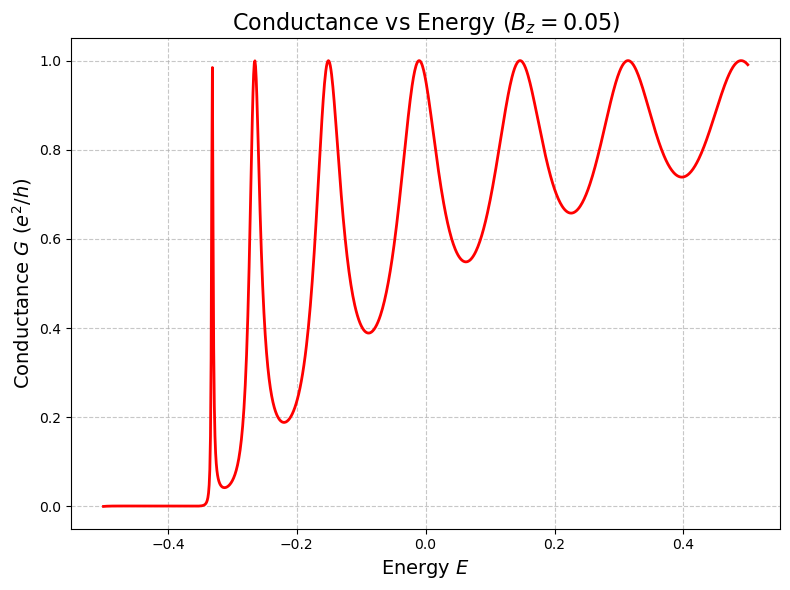

5.0


In [ ]:
# 设定固定的 Bz 和要扫描的能量 E 范围
Bz = 0.05
E_values = np.linspace(-0.5, 0.5, 1001)  
G_values = []
eta = 1e-6

print(f"固定 Bz = {Bz}, 开始使用 RGF 算法扫描能量 E 并计算电导...")

# 1. 构建中心区哈密顿量列表 (2x2 版本)
H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz, i)
    H_q_list.append(H_q_i)

# 2. 🚨 核心修正：右电极必须严格保持规范连续 (Bz, yshumu)
#H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz, yshumu) 

# 3. 开始扫描能量 E
for E in tqdm(E_values, desc="Calculating Conductance vs Energy"):
    # 调用 RGF 算法
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 计算展宽矩阵
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)

    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))  # 适度缩小宽度，让比例更协调

# 点数较多时(301点)，去掉 marker 能让曲线看起来更干净平滑
plt.plot(E_values, G_values, linestyle='-', color='r', linewidth=2)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(rf'Conductance vs Energy ($B_z = {Bz}$)', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 4. 命名修正：去掉了不再存在的超导参数 del={delta}
params_str_1 = f"leiN={leiN}_m={m}_A={A}_B={B}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
save_fig_by_title_1('G_' + params_str_1)

# 显示图像
plt.show()
print(Bz*yshumu*xshumu )

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导...


Scanning Bz: 100%|██████████| 1001/1001 [00:11<00:00, 84.05it/s]


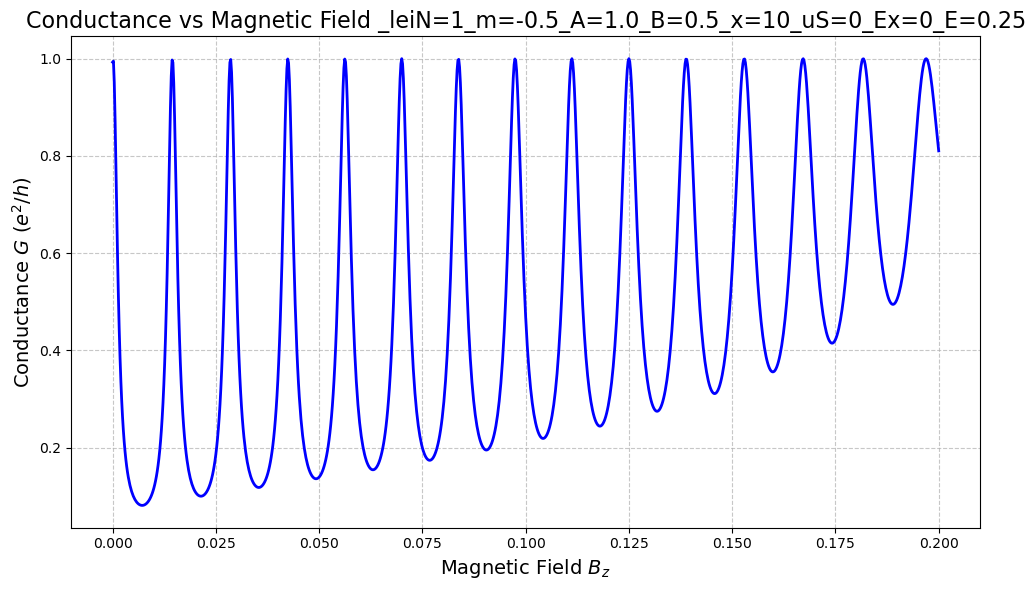

In [113]:

# 设定固定的 E 和要扫描的 Bz 范围
E = 0.25
Bz_values = np.linspace(0, 0.2, 1001)
G_values = []
eta = 1e-6

print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导...")

# 使用 tqdm 添加进度条
for Bz_1 in tqdm(Bz_values, desc="Scanning Bz"):
    # 1. 根据当前的 Bz_1 重新生成中间区的哈密顿量列表 H_q_list
    H_q_list = []
    for i in range(yshumu):
        
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, i)
        H_q_list.append(H_q_i)

    # 🚨 核心修正 2：必须解开注释！右电极必须严格保持规范连续 (传入 Bz_1, yshumu)
    #H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu) 
        
    # 2. 调用新版 RGF 格林函数计算模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 3. 计算单层的展宽矩阵
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 4. 直接计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点
    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(10, 6)) # 稍微调宽一点，让曲线舒展

# 101个点比较密集，去掉 marker='o' 直接用实线，画出来的线更平滑干净
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

params_str_1 = f"leiN={leiN}_m={m}_A={A}_B={B}_x={xshumu}_uS={uS}_Ex={Ex}_E={E}"
# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(fr'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'Conductance vs Magnetic Field _{params_str_1}', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 更新保存命名（去掉超导参数 delta）

# 如果你需要自动保存图片，取消下面两行的注释
# save_fig_by_title_1('G_Bz_' + params_str_1)

# 显示图像
plt.show()

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导...


Scanning Bz: 100%|██████████| 1001/1001 [00:11<00:00, 85.42it/s]


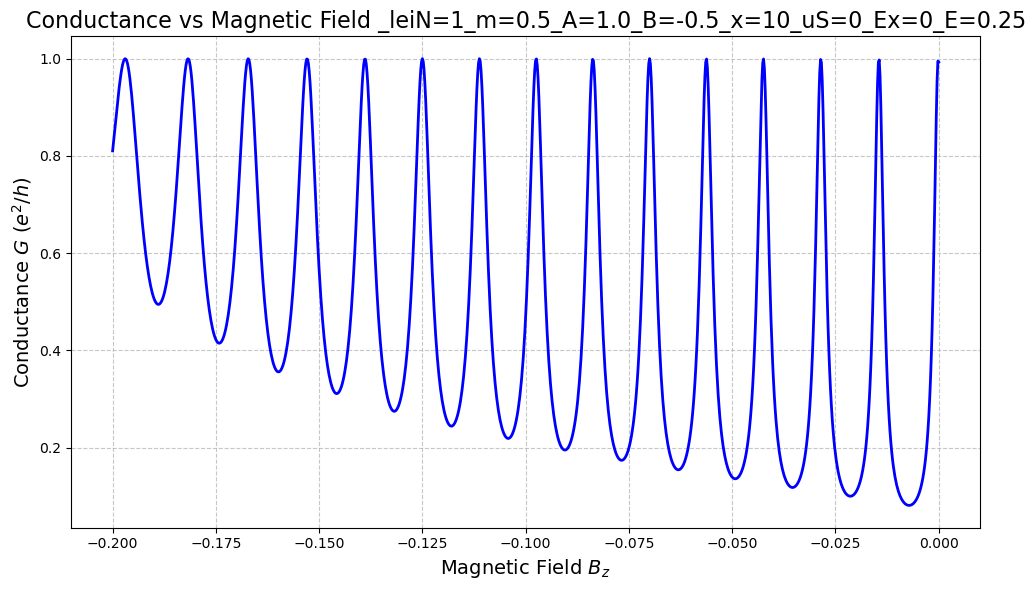

In [126]:
# 设定固定的 E 和要扫描的 Bz 范围--------------2
E = 0.25
Bz_values = np.linspace(-0.2, 0, 1001)
G_values = []
eta = 1e-6

print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导...")

# 使用 tqdm 添加进度条
for Bz_1 in tqdm(Bz_values, desc="Scanning Bz"):
    # 1. 根据当前的 Bz_1 重新生成中间区的哈密顿量列表 H_q_list
    H_q_list = []
    for i in range(yshumu):
        
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, i)
        H_q_list.append(H_q_i)

    # 🚨 核心修正 2：必须解开注释！右电极必须严格保持规范连续 (传入 Bz_1, yshumu)
    #H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu) 
        
    # 2. 调用新版 RGF 格林函数计算模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 3. 计算单层的展宽矩阵
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 4. 直接计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点
    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(10, 6)) # 稍微调宽一点，让曲线舒展

# 101个点比较密集，去掉 marker='o' 直接用实线，画出来的线更平滑干净
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

params_str_1 = f"leiN={leiN}_m={m}_A={A}_B={B}_x={xshumu}_uS={uS}_Ex={Ex}_E={E}"
# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(fr'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'Conductance vs Magnetic Field _{params_str_1}', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 更新保存命名（去掉超导参数 delta）

# 如果你需要自动保存图片，取消下面两行的注释
# save_fig_by_title_1('G_Bz_' + params_str_1)

# 显示图像
plt.show()

固定 Bz = 0.005, E = 0, 开始扫描无序强度 W 并计算电导...


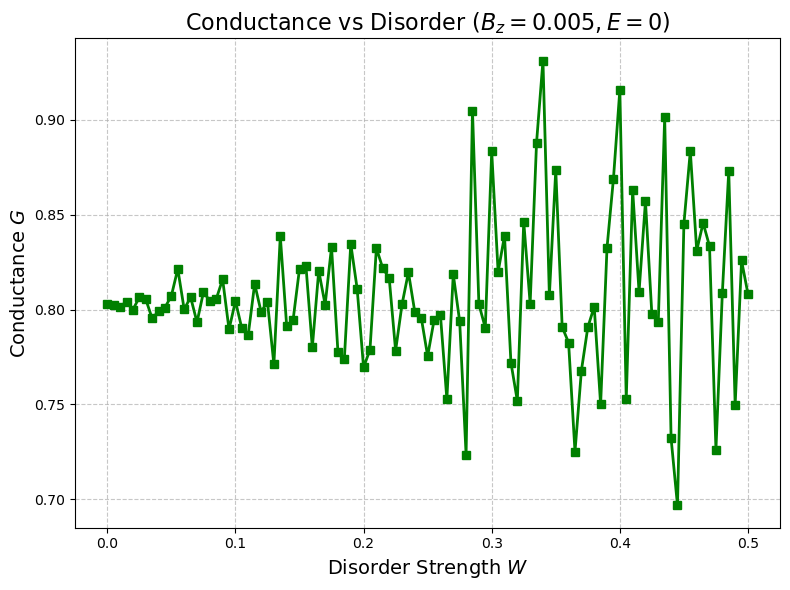

In [90]:
# 1. 设定固定的参数和要扫描的无序强度 W 范围
Bz = 0.005
E = 0
W_values = np.linspace(0, 0.5, 101)  # W 从 0 扫描到 1
G_values = []
eta = 1e-6

# 提前把 uS_set 转成 numpy 数组，方便后面做向量化加法
uS_set_base = np.array(uS_set)

print(f"固定 Bz = {Bz}, E = {E}, 开始扫描无序强度 W 并计算电导...")

# 3. 开始扫描无序强度 W
for W in W_values:
    H_q_list = []
    
    # 因为每次 W 改变，中心区的随机势能地貌都会完全改变，所以必须在这里重新生成 H_q_list
    for i in range(yshumu):
        # 为当前第 i 层生成独立的随机无序势能阵列，范围是 [-W/2, W/2]
        disorder_array = (np.random.rand(xshumu) - 0.5) * W
        
        # 将无序叠加到本底势能上
        uS_set_disorder = uS_set_base + disorder_array
        
        # 生成这一层的哈密顿量并加入列表 (传入带有无序的势能)
        H_q_i = H_onstie(m, B, a, uS_set_disorder, xshumu, Nd, A, Bz, i)
        H_q_list.append(H_q_i)
        
    # 右电极：必须保持规范连续 (Bz, yshumu)！并且电极必须是完美的，不加无序 (传入 uS_set_base)
    #H_r = H_onstie(m, B, a, uS_set_base, 0, 0, xshumu, 4, A, Bz, yshumu) 

    # 调用新版 RGF 格林函数计算模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 计算单层的展宽矩阵 (维度: 160 x 160)
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 直接计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点并打印进度
    G_values.append(G_real)
    # print(f"W = {W:.3f}, 电导 G = {G_real:.6e}")

# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))
# 换个颜色区分一下，比如用绿色 'g' 画 W-G 图
plt.plot(W_values, G_values, marker='s', linestyle='-', color='g', linewidth=2, markersize=6)

# 设置坐标轴标签和标题
plt.xlabel(r'Disorder Strength $W$', fontsize=14)
plt.ylabel(r'Conductance $G$', fontsize=14)
plt.title(rf'Conductance vs Disorder ($B_z = {Bz}, E = {E}$)', fontsize=16)

# 设置 y 轴范围稍微宽一点，方便看平整度 (假设量子化平台在 1 或 2，你可以根据实际结果调整)
# plt.ylim(0.9, 2.1) 

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# filename = os.path.join(save_dir, "G_vs_W_RGF.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

固定 E = 0.0, 设定无序 W = 0.1, 正在生成固定无序样本...
开始使用 RGF 算法扫描磁场 Bz 并计算电导...


Scanning Bz: 100%|██████████| 501/501 [00:08<00:00, 55.77it/s]


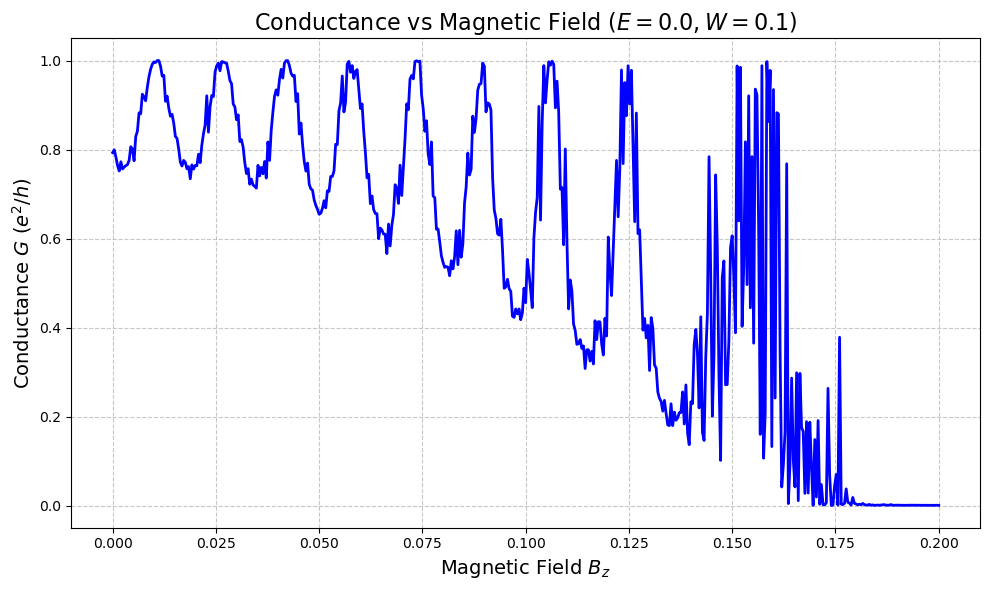

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# 1. 设定固定的 E, W 和要扫描的 Bz 范围
E = 0.0
W = 0.1
Bz_values = np.linspace(0, 0.2, 501)  # 扫描 101 个点
G_values = []
eta = 1e-6

# 提前把 uS_set 转成 numpy 数组
uS_set_base = np.array(uS_set)

print(f"固定 E = {E}, 设定无序 W = {W}, 正在生成固定无序样本...")

# 🎯 核心物理修正：在 B_z 循环【外部】生成整个 2D 样品的固定的无序地貌！
# 这样保证了我们在整个磁场扫描过程中，测量的是同一块“脏”样品


print("开始使用 RGF 算法扫描磁场 Bz 并计算电导...")

# 2. 开始扫描磁场 Bz
for Bz_1 in tqdm(Bz_values, desc="Scanning Bz"):
    disorder_matrix = (np.random.rand(yshumu, xshumu) - 0.5) * W
    H_q_list = []
    
    # 构建包含【固定无序】的中心区哈密顿量
    for i in range(yshumu):
        # 提取当前层 i 预先生成好的无序势能
        disorder_array = disorder_matrix[i, :]
        
        # 将无序叠加到本底势能上
        uS_set_disorder = uS_set_base + disorder_array
        
        # 传入带有无序的势能以及当前的磁场 Bz_1 (适配 2x2 模型参数)
        H_q_i = H_onstie(m, B, a, uS_set_disorder, xshumu, Nd, A, Bz_1, i)
        H_q_list.append(H_q_i)
        
    # 🚨 右电极：必须在循环内部生成以保持规范连续！
    # 注意：电极必须是完美的晶格，所以传入的是 uS_set_base (不含无序)
    #H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu) 

    # 3. 调用 RGF 格林函数计算模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 4. 计算展宽矩阵
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 5. 直接计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(10, 6))

# 画平滑的实线
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(rf'Conductance vs Magnetic Field ($E = {E}, W = {W}$)', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 保存图像 (去掉了冗余的 delta 标签)
# params_str_2 = f"leiN={leiN}_m={m}_A={A}_B={B}_x={xshumu}_W={W}_E={E}"
# save_fig_by_title_1('G_Bz_Disorder_' + params_str_2)

# 显示图像
plt.show()